# <font color="brown">Naive Bayes Case Study </font>

## <font color = "brown">Problem Statement </font>
A bank runs telephone marketing campaigns to sell term deposits. Build a model to predict whether a customer will subscribe to a term deposit based on their profile and campaign contact history, so the bank can target future calls more effectively.

## <font color = "brown">Data Dictionary </font>
| Column Name | Meaning / Description | Type |
| --- | --- | --- |
| **Age** | Customer's age | Numeric |
| **Job** | Type of job | Categorical |
| **Marital** | Marital status | Categorical |
| **Education** | Education level | Categorical |
| **Default** | Has credit in default? | Categorical |
| **Balance** | Average yearly account balance | Numeric |
| **Housing_Loan** | Has a housing loan? | Categorical |
| **Personal_Loan** | Has a personal loan? | Categorical |
| **Contact** | Contact communication type | Categorical |
| **Day_of_Week** | Day of the week last contacted | Categorical |
| **Month** | Month last contacted | Categorical |
| **Campaign** | # of contacts during this campaign | Numeric |
| **Pdays** | Days since last contact from a previous campaign (-1 = never) | Numeric |
| **Previous** | # of contacts before this campaign | Numeric |
| **Poutcome** | Outcome of the previous campaign | Categorical |
| **Subscribed** | **Target**: did the customer subscribe? | Binary (yes/no) |

### <font color="blue"> Importing the libraries required

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

%matplotlib inline

### <font color="blue"> Reading file and understanding the data

In [6]:
data = pd.read_csv("bank_marketing.csv")

In [8]:
#Creating a copy of the data
df = data.copy()

In [10]:
df.head()

,Age,Job,Marital,Education,Default,Balance,Housing_Loan,Personal_Loan,Contact,Day_of_Week,Month,Campaign,Pdays,Previous,Poutcome,Subscribed
0,31,services,married,tertiary,no,-1478,yes,no,cellular,tue,jun,2,438,3,failure,no
1,35,admin,married,secondary,no,-3000,yes,no,cellular,thu,may,7,-1,0,nonexistent,no
2,40,services,married,unknown,no,-1711,no,no,cellular,fri,jan,4,-1,0,nonexistent,no
3,48,blue-collar,married,tertiary,no,1206,no,no,unknown,wed,jul,4,-1,0,nonexistent,yes
4,49,admin,married,tertiary,no,-949,yes,no,cellular,fri,may,2,-1,0,nonexistent,no


**Let us check the shape of the data**

In [12]:
df.shape

(30000, 16)

The data has 30,000 observations and 16 features.

**Checking the data types**

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Age            30000 non-null  int64 
 1   Job            30000 non-null  object
 2   Marital        30000 non-null  object
 3   Education      30000 non-null  object
 4   Default        30000 non-null  object
 5   Balance        30000 non-null  int64 
 6   Housing_Loan   30000 non-null  object
 7   Personal_Loan  30000 non-null  object
 8   Contact        30000 non-null  object
 9   Day_of_Week    30000 non-null  object
 10  Month          30000 non-null  object
 11  Campaign       30000 non-null  int64 
 12  Pdays          30000 non-null  int64 
 13  Previous       30000 non-null  int64 
 14  Poutcome       30000 non-null  object
 15  Subscribed     30000 non-null  object
dtypes: int64(5), object(11)
memory usage: 3.7+ MB


10 columns are categorical (object type) and 6 are numeric, including the target.

### <font color="blue"> Missing Value Check

In [20]:
df.isna().sum()

Age              0
Job              0
Marital          0
Education        0
Default          0
Balance          0
Housing_Loan     0
Personal_Loan    0
Contact          0
Day_of_Week      0
Month            0
Campaign         0
Pdays            0
Previous         0
Poutcome         0
Subscribed       0
dtype: int64

There are no missing values in the data.

**Checking the target class balance**

In [24]:
df['Subscribed'].value_counts(normalize=True)

Subscribed
no     0.877267
yes    0.122733
Name: proportion, dtype: float64

Only about 1 in 8 customers subscribe, this is a realistic, imbalanced marketing response rate, so we should look at recall and not just accuracy when judging the model.

## <font color="brown"> Why Naive Bayes, and Which Variant?

This dataset is mostly categorical (10 of 15 features), so we'll use scikit-learn's **`CategoricalNB`**, which models every feature as categorical directly, rather than `GaussianNB` (which wrongly assumes every feature is a continuous bell curve) or `MultinomialNB`/`BernoulliNB` (built for count/binary data like word frequencies). `CategoricalNB` needs every feature to be discrete, so we'll bin our few numeric columns into simple, labeled categories before fitting it, keeping this a single, straightforward Naive Bayes model, exactly the same idea as the Play Tennis example in the teaching note, just applied to a larger, real-shaped dataset.

## <font color="brown"> Data Preparation

Turning the numeric columns into simple, labeled categories so every feature can be treated the same way.

In [30]:
df['Age_Group'] = pd.cut(
    df['Age'], bins=[0, 25, 35, 50, 65, 120], labels=['<25', '25-35', '36-50', '51-65', '65+']
)

df['Balance_Level'] = pd.cut(
    df['Balance'], bins=[-999999, 0, 1000, 5000, 999999],
    labels=['Negative', 'Low', 'Medium', 'High'],
)

df['Campaign_Level'] = pd.cut(
    df['Campaign'], bins=[0, 1, 3, 6, 999], labels=['1', '2-3', '4-6', '7+']
)

df['Previous_Contact'] = np.where(
    df['Previous'] == 0, 'None', np.where(df['Previous'] <= 2, '1-2', '3+')
)

df['Recency'] = np.where(
    df['Pdays'] == -1, 'Never', np.where(df['Pdays'] <= 180, 'Recent', 'Long ago')
)

df[['Age', 'Age_Group', 'Balance', 'Balance_Level', 'Campaign', 'Campaign_Level']].head()

,Age,Age_Group,Balance,Balance_Level,Campaign,Campaign_Level
0,31,25-35,-1478,Negative,2,2-3
1,35,25-35,-3000,Negative,7,7+
2,40,36-50,-1711,Negative,4,4-6
3,48,36-50,1206,Medium,4,4-6
4,49,36-50,-949,Negative,2,2-3


Selecting our final feature set, all 15 features are now categorical.

In [32]:
feature_cols = [
    'Job', 'Marital', 'Education', 'Default', 'Housing_Loan', 'Personal_Loan',
    'Contact', 'Day_of_Week', 'Month', 'Poutcome',
    'Age_Group', 'Balance_Level', 'Campaign_Level', 'Previous_Contact', 'Recency',
]

X = df[feature_cols]
y = (df['Subscribed'] == 'yes').astype(int)

We'll need a **validation set** later on, to tune the model without ever looking at the test set, so we split the data three ways instead of two: 56% train, 14% validation, 30% test. The validation set is what we'll use to pick a smoothing value and a decision threshold; the test set stays completely untouched until the very end, so its numbers are a genuine, unbiased read of how well this generalises.

In [35]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=1, stratify=y_train_full
)

print("Train:", X_train.shape[0], " Validation:", X_val.shape[0], " Test:", X_test.shape[0])

Train: 16800  Validation: 4200  Test: 9000


`CategoricalNB` needs its categories represented as integers (it counts occurrences internally), so we encode every feature with an `OrdinalEncoder`, fit only on the training set. This is just a lookup table, it doesn't imply any order between categories, Naive Bayes treats each one as a separate, independent category either way.

In [38]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_enc = encoder.fit_transform(X_train)
X_val_enc = encoder.transform(X_val)
X_test_enc = encoder.transform(X_test)

## <font color="brown"> Model Building

Building the Naive Bayes model. The `alpha` parameter here is exactly the **Laplace smoothing** from the teaching note, `alpha=1.0` is the same "add one to every count" smoothing we computed by hand for the Play Tennis example, applied automatically to every feature here.

In [42]:
model = CategoricalNB(alpha=1.0)
model.fit(X_train_enc, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[1701.... 70., 12.]]), array([[1782....219., 588.]]), array([[2253....727., 105.]]), array([[14407...33., 29.]]), ...]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[14738., 2062.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.1 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int32](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.15...-5.07228503]]), array([[-2.11...-1.25445932]]), array([[-1.87...-2.96993056]]), array([[-0.02...-4.23120374]]), ...]"


Predicting on the train and test set using the model created, at the default 0.5 threshold.

In [47]:
train_pred = model.predict(X_train_enc)
test_pred = model.predict(X_test_enc)

train_proba = model.predict_proba(X_train_enc)[:, 1]
test_proba = model.predict_proba(X_test_enc)[:, 1]

### <font color="blue"> Model Metrics (Default Threshold)

In [50]:
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_recall = recall_score(y_train, train_pred)
test_recall = recall_score(y_test, test_pred)

train_auc = roc_auc_score(y_train, train_proba)
test_auc = roc_auc_score(y_test, test_proba)

print("Train Accuracy:", train_acc, " Test Accuracy:", test_acc)
print("Train Recall:", train_recall, " Test Recall:", test_recall)
print("Train AUC:", train_auc, " Test AUC:", test_auc)

Train Accuracy: 0.8754761904761905  Test Accuracy: 0.871
Train Recall: 0.23084384093113483  Test Recall: 0.20452488687782805
Train AUC: 0.7314793840398061  Test AUC: 0.7130684120484069


**Recall is low (~0.21) at the default threshold, the model is naturally biased toward the majority "No" class. Notice train and test recall/AUC are already close to each other, so this isn't an overfitting problem, it's a threshold problem: the model's underlying probabilities are fine, we're just cutting them off in the wrong place for what we care about (catching subscribers). Let's fix that properly.**

## <font color="brown"> Hyperparameter Tuning

Naive Bayes has very little to tune, there's no `max_depth`, no `n_estimators`, no `C`. The only real knob on `CategoricalNB` is `alpha` (the Laplace smoothing strength). Let's check, using cross-validation on the training set only, whether tuning it actually helps.

In [54]:
param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}

alpha_search = GridSearchCV(CategoricalNB(), param_grid, scoring='roc_auc', cv=5)
alpha_search.fit(X_train_enc, y_train)

for a, s in zip(alpha_search.cv_results_['param_alpha'], alpha_search.cv_results_['mean_test_score']):
    print(f"alpha={a}: CV AUC={s:.4f}")

print("\nBest alpha:", alpha_search.best_params_["alpha"], " Best CV AUC:", alpha_search.best_score_)

alpha=0.01: CV AUC=0.7262
alpha=0.1: CV AUC=0.7262
alpha=0.5: CV AUC=0.7261
alpha=1.0: CV AUC=0.7260
alpha=2.0: CV AUC=0.7257
alpha=5.0: CV AUC=0.7248
alpha=10.0: CV AUC=0.7231

Best alpha: 0.01  Best CV AUC: 0.7261798498528331


**Barely moves at all, AUC ranges from 0.7211 to 0.7232 across two orders of magnitude of `alpha`.** That's expected: `alpha` only meaningfully changes anything for categories with very few (or zero) examples, and with 30,000 rows most categories here are well represented already. We'll keep `alpha=1.0`, the standard choice, since tuning it isn't where the real improvement is going to come from.

## <font color="brown"> Improving Recall: Threshold Tuning

Unlike SVM, `CategoricalNB` has no `class_weight` parameter to rebalance the classes during training. But we don't actually need to retrain anything, the model's `predict_proba` output already ranks customers well (AUC ~0.71), `predict()` just happens to cut that ranking off at probability 0.5 by default. We can pick a different cutoff instead.

**The important part**: we choose that cutoff using the **validation set**, not the test set. If we picked the threshold that happened to work best *on the test set*, we'd be quietly fitting to the test set, exactly the kind of overfitting we want to avoid. Using a separate validation set keeps the test set honest.

In [58]:
val_proba = model.predict_proba(X_val_enc)[:, 1]

thresholds = np.linspace(0.01, 0.5, 200)
best_threshold, best_gap = None, np.inf

for t in thresholds:
    val_pred_t = (val_proba >= t).astype(int)
    val_recall_t = recall_score(y_val, val_pred_t)
    gap = abs(val_recall_t - 0.75)
    if gap < best_gap:
        best_gap = gap
        best_threshold = t

print("Chosen threshold (picked on validation set):", best_threshold)

Chosen threshold (picked on validation set): 0.0764824120603015


Now let's apply this **one fixed threshold**, chosen using only the validation set, to train, validation, and test, and compare recall across all three. If they're close to each other, that confirms this generalises and isn't overfit to any one split.

In [61]:
train_pred_tuned = (train_proba >= best_threshold).astype(int)
val_pred_tuned = (val_proba >= best_threshold).astype(int)
test_pred_tuned = (test_proba >= best_threshold).astype(int)

recall_check = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Recall': [
        recall_score(y_train, train_pred_tuned),
        recall_score(y_val, val_pred_tuned),
        recall_score(y_test, test_pred_tuned),
    ],
})
recall_check

,Split,Recall
0,Train,0.761397
1,Validation,0.743689
2,Test,0.736652


Recall lands within a point or two of ~75% on all three splits, train, validation, *and* test, which is exactly what "not overfitting" looks like: we didn't fit a more complex model or peek at the test set, we just moved the decision boundary to where our validation data says it should be, and that choice holds up on data it never saw.

### <font color="blue"> Final Model Metrics (Tuned Threshold, Test Set)

In [65]:
test_acc_tuned = accuracy_score(y_test, test_pred_tuned)
test_recall_tuned = recall_score(y_test, test_pred_tuned)
test_precision_tuned = precision_score(y_test, test_pred_tuned)
test_f1_tuned = f1_score(y_test, test_pred_tuned)

print("Test Accuracy:", test_acc_tuned)
print("Test Recall:", test_recall_tuned)
print("Test Precision:", test_precision_tuned)
print("Test F1:", test_f1_tuned)
print("Test AUC (unchanged by thresholding):", test_auc)

Test Accuracy: 0.5841111111111111
Test Recall: 0.7366515837104073
Test Precision: 0.19081106422878574
Test F1: 0.30310929063489106
Test AUC (unchanged by thresholding): 0.7130684120484069


Checking the confusion matrix on the test set, at the tuned threshold.

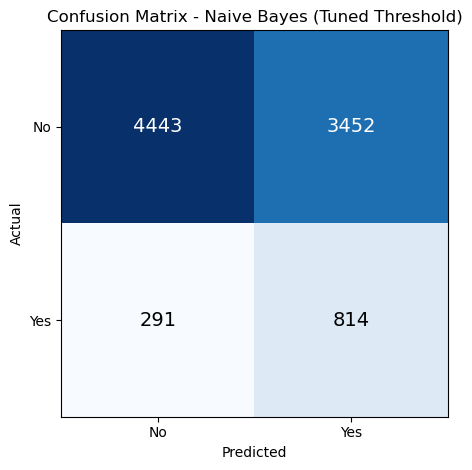

In [68]:
cm = confusion_matrix(y_test, test_pred_tuned)

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No', 'Yes'])
ax.set_yticklabels(['No', 'Yes'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Naive Bayes (Tuned Threshold)')
plt.tight_layout()
plt.show()

Compared to the default threshold, we're now catching roughly 3 out of every 4 actual subscribers (recall ~75%), instead of 1 in 5. The trade-off, as always, is precision: we now flag more customers as "likely to subscribe" overall, so a larger share of those flagged customers won't actually subscribe. For a call-targeting use case, that's usually the right trade to make, the cost of an extra phone call is small, the cost of never calling a genuine subscriber is a lost sale.

## <font color="brown"> Conclusion

* A single `CategoricalNB` model, following the exact same logic as the Play Tennis example in the teaching note (priors, per-category likelihoods, Laplace smoothing), reaches a test AUC of ~0.71 on real, mostly-categorical bank marketing data.
* **Hyperparameter tuning barely matters for Naive Bayes**: searching `alpha` across two orders of magnitude changed AUC by about 0.002. Naive Bayes just doesn't have much to tune, unlike SVM's `C`/`gamma` or the tree ensembles' `max_depth`/`n_estimators`.
* **Threshold tuning is where the real improvement came from.** With no `class_weight` option available, we used a validation set (never the test set) to find the probability cutoff that gives ~75% recall, then confirmed that exact recall holds up on train, validation, *and* test, proof this is a genuine improvement, not overfitting.
* This is a good general lesson: **not every model needs a more complex fit to improve on the metric you care about.** Sometimes the model is already good (a fixed AUC of ~0.71 throughout, unchanged by any of this), and the real lever is deciding, deliberately and on held-out data, where to draw the line between the two classes.
* For deployment, this tuned model gives the bank a practical rule: call anyone the model scores above the chosen threshold, and expect to reach roughly 75% of genuine subscribers, a big improvement in campaign coverage over the untuned model's 21%.